<a href="https://colab.research.google.com/github/Leonardo-dias-prog/Projeto_Petshop/blob/main/Programa%C3%A7%C3%A3o_em_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  PROBLEMA 1 — SERVIÇO DE ESTÉTICA (Maximização de Lucro)

Parâmetros:
  Tempo Banho   = 0.8333 h (50 min)
  Tempo Tosa    = 1.5000 h (90 min)
  Tempo/dia     = 8.0 h
  Lucro Banho   = R$ 45
  Lucro Tosa    = R$ 55

── Solução Contínua (relaxação LP) ──
  x* (banhos) = 9.60
  y* (tosas)  = 0.00
  Z*          = R$ 432.00

── Enumeração de Combinações Viáveis ──
  Banhos  Tosas  Tempo (h)  Lucro (R$)
  ──────  ─────  ─────────  ──────────
       9      0     7.5000      405.00 ◄ ÓTIMO
       6      2     8.0000      380.00
       7      1     7.3333      370.00
       8      0     6.6667      360.00
       4      3     7.8333      345.00
       5      2     7.1667      335.00
       6      1     6.5000      325.00
       7      0     5.8333      315.00
       2      4     7.6667      310.00
       3      3     7.0000      300.00
       4      2     6.3333      290.00
       5      1     5.6667      280.00
       0      5     7.5000      275.00
       6      0     5.0000      270.00
     

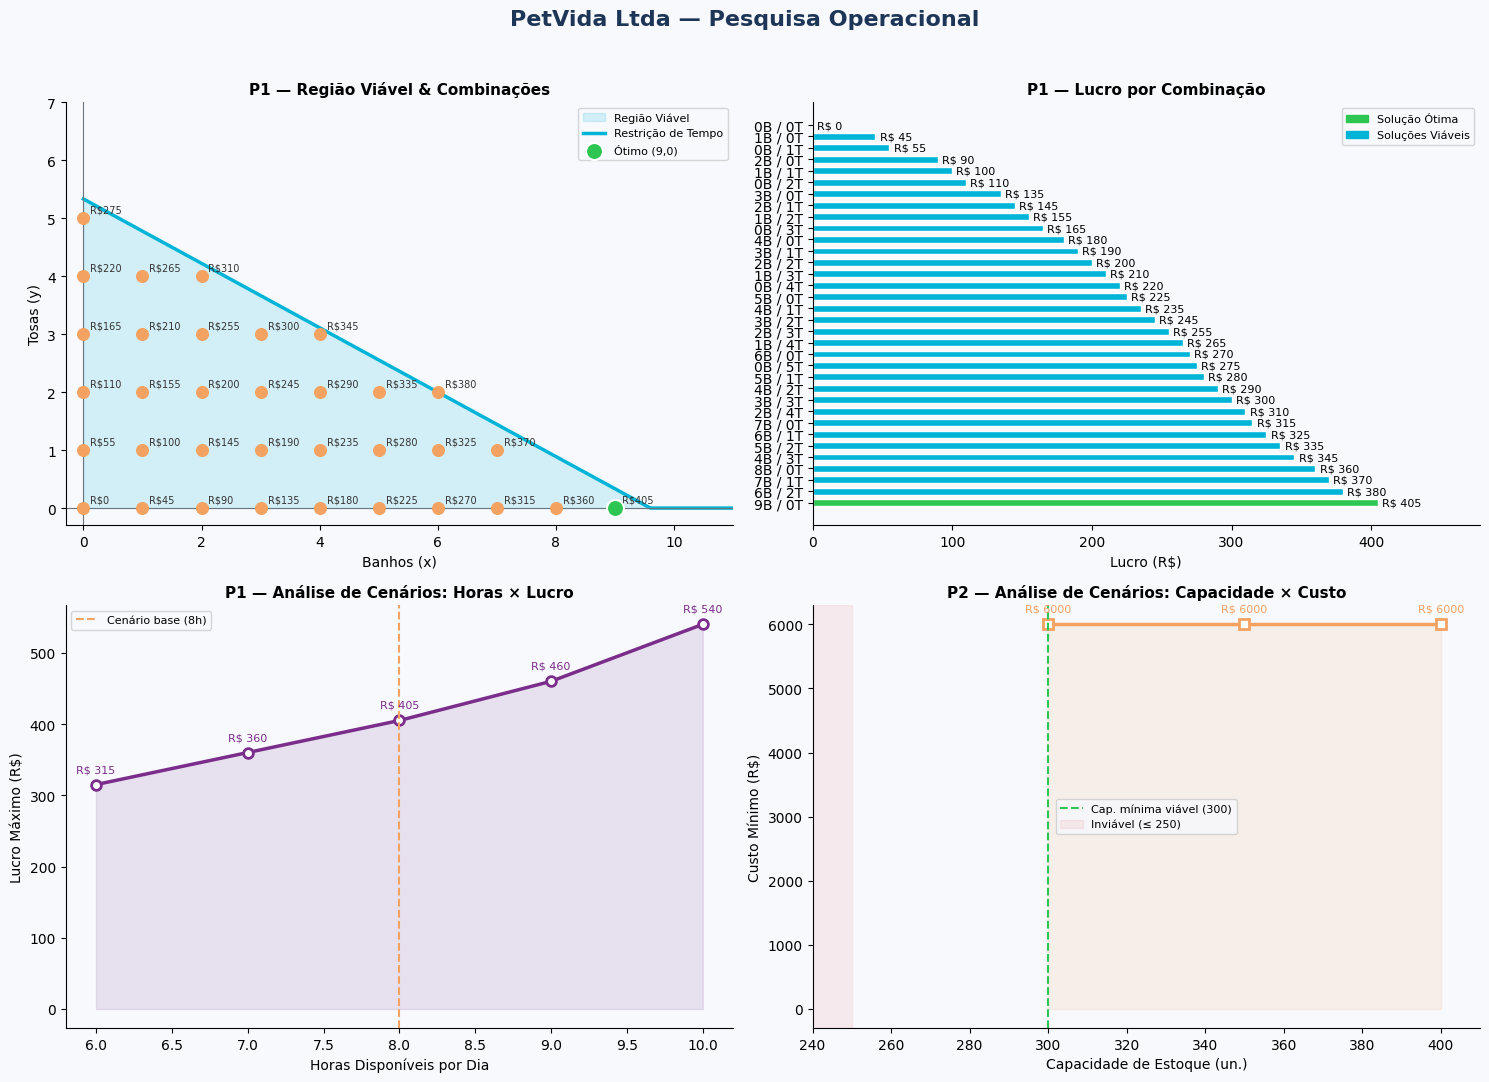


  RESUMO EXECUTIVO — PetVida Ltda

PROBLEMA 1 — Serviço de Estética
  Modelo:    Max Z = 45x + 55y
  Restrição: 0,8333x + 1,5y ≤ 8  |  x,y ≥ 0 inteiro
  Solução:   9 banhos, 0 tosas  →  R$ 405/dia
  Insight:   Banho tem retorno/hora maior (R$54/h vs R$36,7/h)

PROBLEMA 2 — Controle de Estoque
  Modelo:    Min Z = 30x + 15y
  Restrições: x ≥ 100, y ≥ 200, x+y ≤ capacidade
  Diagnóstico: INVIÁVEL com capacidade=250 (deficit=50 un.)
  Solução c/ cap=300: x=100, y=200 → Custo = R$ 6.000
  Ações:     Reposição semanal / expandir armazenamento



In [1]:
"""
=============================================================
  PetVida Ltda — Pesquisa Operacional
  Modelagem Completa + Análise de Cenários
  Usando: scipy.optimize.linprog  (sem Excel Solver)
=============================================================
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import linprog

# ─────────────────────────────────────────────────────────────
#  CONFIGURAÇÕES GLOBAIS DE ESTILO
# ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "#f7f9fc",
    "axes.facecolor": "#f7f9fc",
})

CYAN   = "#00b4d8"
GREEN  = "#2dc653"
ORANGE = "#f4a261"
RED    = "#e63946"
PURPLE = "#7b2d8b"
GRAY   = "#6c757d"

# =============================================================
#  PROBLEMA 1 — MAXIMIZAÇÃO DE LUCRO: BANHO vs TOSA
# =============================================================
print("=" * 60)
print("  PROBLEMA 1 — SERVIÇO DE ESTÉTICA (Maximização de Lucro)")
print("=" * 60)

# ── Dados ────────────────────────────────────────────────────
tempo_banho   = 50 / 60   # horas  ≈ 0,8333
tempo_tosa    = 1.5       # horas
tempo_dia     = 8.0       # horas disponíveis/dia
lucro_banho   = 45        # R$
lucro_tosa    = 55        # R$

print(f"\nParâmetros:")
print(f"  Tempo Banho   = {tempo_banho:.4f} h ({50} min)")
print(f"  Tempo Tosa    = {tempo_tosa:.4f} h (90 min)")
print(f"  Tempo/dia     = {tempo_dia} h")
print(f"  Lucro Banho   = R$ {lucro_banho}")
print(f"  Lucro Tosa    = R$ {lucro_tosa}")

# ── Modelo PL ────────────────────────────────────────────────
# Max Z = 45x + 55y
# s.a.  0.8333x + 1.5y ≤ 8
#       x, y ≥ 0  (inteiro)
#
# linprog minimiza → invertemos o sinal
c1      = [-lucro_banho, -lucro_tosa]
A_ub1   = [[tempo_banho, tempo_tosa]]
b_ub1   = [tempo_dia]
bounds1 = [(0, None), (0, None)]

res1 = linprog(c1, A_ub=A_ub1, b_ub=b_ub1,
               bounds=bounds1, method="highs")

x_cont, y_cont = res1.x
lucro_cont      = -res1.fun

print(f"\n── Solução Contínua (relaxação LP) ──")
print(f"  x* (banhos) = {x_cont:.2f}")
print(f"  y* (tosas)  = {y_cont:.2f}")
print(f"  Z*          = R$ {lucro_cont:.2f}")

# ── Solução inteira via enumeração (problema pequeno) ────────
melhor_lucro = 0
melhor_combo = (0, 0)
resultados_p1 = []

max_banhos = int(tempo_dia / tempo_banho) + 1
for x in range(max_banhos + 1):
    for y in range(int(tempo_dia / tempo_tosa) + 1):
        tempo_usado = tempo_banho * x + tempo_tosa * y
        if tempo_usado <= tempo_dia + 1e-6:
            lucro = lucro_banho * x + lucro_tosa * y
            resultados_p1.append((x, y, round(tempo_usado, 4), lucro))
            if lucro > melhor_lucro:
                melhor_lucro = lucro
                melhor_combo = (x, y)

print(f"\n── Enumeração de Combinações Viáveis ──")
print(f"  {'Banhos':>6}  {'Tosas':>5}  {'Tempo (h)':>9}  {'Lucro (R$)':>10}")
print(f"  {'─'*6}  {'─'*5}  {'─'*9}  {'─'*10}")
for row in sorted(resultados_p1, key=lambda r: -r[3]):
    mark = " ◄ ÓTIMO" if (row[0], row[1]) == melhor_combo else ""
    print(f"  {row[0]:>6}  {row[1]:>5}  {row[2]:>9.4f}  {row[3]:>10.2f}{mark}")

print(f"\n✔️ Melhor solução inteira: {melhor_combo[0]} banhos, {melhor_combo[1]} tosas")
print(f"  Lucro máximo = R$ {melhor_lucro:.2f}/dia")
print(f"  Lucro por hora: Banho = R$ {lucro_banho/tempo_banho:.2f} | Tosa = R$ {lucro_tosa/tempo_tosa:.2f}")

# ── Análise de Cenários — Problema 1 ────────────────────────
print("\n── Análise de Cenários (variação do tempo disponível) ──")
cenarios_tempo = [6, 7, 8, 9, 10]
print(f"  {'Horas/dia':>9}  {'Banhos':>6}  {'Tosas':>5}  {'Lucro (R$)':>10}")
print(f"  {'─'*9}  {'─'*6}  {'─'*5}  {'─'*10}")
lucros_cenarios = []
for td in cenarios_tempo:
    mb, mc, ml = 0, 0, 0
    for x in range(int(td / tempo_banho) + 2):
        for y in range(int(td / tempo_tosa) + 2):
            if tempo_banho * x + tempo_tosa * y <= td + 1e-6:
                l = lucro_banho * x + lucro_tosa * y
                if l > ml:
                    ml, mb, mc = l, x, y
    lucros_cenarios.append(ml)
    print(f"  {td:>9}  {mb:>6}  {mc:>5}  {ml:>10.2f}")


# =============================================================
#  PROBLEMA 2 — CONTROLE DE ESTOQUE (Minimização de Custo)
# =============================================================
print("\n" + "=" * 60)
print("  PROBLEMA 2 — CONTROLE DE ESTOQUE (Minimização de Custo)")
print("=" * 60)

dem_premium  = 100   # unidades mín.
dem_standard = 200   # unidades mín.
custo_p      = 30    # R$/unidade
custo_s      = 15    # R$/unidade
capacidade   = 250   # unidades máx.

print(f"\nParâmetros:")
print(f"  Demanda mínima Premium  = {dem_premium} un.")
print(f"  Demanda mínima Standard = {dem_standard} un.")
print(f"  Custo Premium           = R$ {custo_p}/un.")
print(f"  Custo Standard          = R$ {custo_s}/un.")
print(f"  Capacidade estoque      = {capacidade} un.")
print(f"  Demanda total           = {dem_premium + dem_standard} un.")

# ── Diagnóstico de inviabilidade ─────────────────────────────
print(f"\n── Diagnóstico ──")
demanda_total = dem_premium + dem_standard
if demanda_total > capacidade:
    print(f"  ⚠️ PROBLEMA INVIÁVEL: demanda ({demanda_total}) > capacidade ({capacidade})")
    print(f"  Déficit = {demanda_total - capacidade} unidades")
    print(f"  → Não existe solução factível com o estoque atual.")
else:
    print(f"  ✔️ Problema viável.")

# ── Cenários de capacidade ────────────────────────────────────
print(f"\n── Análise de Cenários (variação de capacidade) ──")
caps = [250, 275, 300, 350, 400]
print(f"  {'Capacidade':>10}  {'Viável':>6}  {'P (un.)':>7}  {'S (un.)':>7}  {'Custo (R$)':>10}  {'Ociosidade':>10}")
print(f"  {'─'*10}  {'─'*6}  {'─'*7}  {'─'*7}  {'─'*10}  {'─'*10}")

custos_p2 = []
caps_ok   = []
for cap in caps:
    # Min Z = 30x + 15y
    # s.a.  x ≥ 100, y ≥ 200, x+y ≤ cap
    c2      = [custo_p, custo_s]
    A_ub2   = [[1, 1]]
    b_ub2   = [cap]
    bnd2    = [(dem_premium, None), (dem_standard, None)]

    res2 = linprog(c2, A_ub=A_ub2, b_ub=b_ub2,
                   bounds=bnd2, method="highs")

    if res2.success:
        xp, xs   = round(res2.x[0]), round(res2.x[1])
        custo_min = res2.fun
        ociosidade = cap - (xp + xs)
        custos_p2.append(custo_min)
        caps_ok.append(cap)
        mark = " ◄ BASE" if cap == dem_premium + dem_standard else ""
        print(f"  {cap:>10}  {'✔️':>6}  {xp:>7}  {xs:>7}  {custo_min:>10.2f}  {ociosidade:>10}{mark}")
    else:
        print(f"  {cap:>10}  {'✗':>6}  {'—':>7}  {'—':>7}  {'—':>10}  {'—':>10}")

# ── Solução ótima com cap=300 ─────────────────────────────────
print(f"\n── Solução Ótima (capacidade = 300) ──")
print(f"  x = {dem_premium} un. de Ração Premium")
print(f"  y = {dem_standard} un. de Ração Standard")
print(f"  Custo mínimo = 30×{dem_premium} + 15×{dem_standard}")
print(f"               = {custo_p*dem_premium} + {custo_s*dem_standard}")
print(f"               = R$ {custo_p*dem_premium + custo_s*dem_standard:.2f}")


# =============================================================
#  VISUALIZAÇÕES
# =============================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("PetVida Ltda — Pesquisa Operacional", fontsize=16,
             fontweight="bold", y=0.98, color="#1d3557")

# ── Gráfico 1: Região Viável P1 ───────────────────────────────
ax1 = axes[0, 0]
x_vals = np.linspace(0, 11, 400)
y_vals = (tempo_dia - tempo_banho * x_vals) / tempo_tosa
y_vals = np.clip(y_vals, 0, None)

ax1.fill_betweenx([0, tempo_dia / tempo_tosa],
                  [0, 0], [tempo_dia / tempo_banho, 0],
                  alpha=0.15, color=CYAN, label="Região Viável")
ax1.plot(x_vals, y_vals, color=CYAN, lw=2.5, label="Restrição de Tempo")
ax1.axhline(0, color=GRAY, lw=0.8)
ax1.axvline(0, color=GRAY, lw=0.8)

for x, y, _, lucro in resultados_p1:
    cor = GREEN if (x, y) == melhor_combo else ORANGE
    ax1.scatter(x, y, color=cor, s=70, zorder=5)
    ax1.annotate(f"R${lucro}", (x, y),
                 textcoords="offset points", xytext=(5, 4),
                 fontsize=7, color="#333")

ax1.scatter(*melhor_combo, color=GREEN, s=150, zorder=6,
            edgecolors="white", linewidth=1.5, label=f"Ótimo ({melhor_combo[0]},{melhor_combo[1]})")
ax1.set_xlabel("Banhos (x)", fontsize=10)
ax1.set_ylabel("Tosas (y)", fontsize=10)
ax1.set_title("P1 — Região Viável & Combinações", fontsize=11, fontweight="bold")
ax1.legend(fontsize=8)
ax1.set_xlim(-0.3, 11)
ax1.set_ylim(-0.3, 7)

# ── Gráfico 2: Lucro por Combinação P1 ───────────────────────
ax2 = axes[0, 1]
labels_p1 = [f"{r[0]}B / {r[1]}T" for r in sorted(resultados_p1, key=lambda r: -r[3])]
lucros_p1  = [r[3] for r in sorted(resultados_p1, key=lambda r: -r[3])]
cores      = [GREEN if (r[0], r[1]) == melhor_combo else CYAN
              for r in sorted(resultados_p1, key=lambda r: -r[3])]

bars = ax2.barh(labels_p1, lucros_p1, color=cores, edgecolor="white", height=0.6)
for bar, val in zip(bars, lucros_p1):
    ax2.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
             f"R$ {val}", va="center", fontsize=8)
ax2.set_xlabel("Lucro (R$)", fontsize=10)
ax2.set_title("P1 — Lucro por Combinação", fontsize=11, fontweight="bold")
ax2.set_xlim(0, max(lucros_p1) * 1.18)
patch_otimo = mpatches.Patch(color=GREEN, label="Solução Ótima")
patch_viavel = mpatches.Patch(color=CYAN, label="Soluções Viáveis")
ax2.legend(handles=[patch_otimo, patch_viavel], fontsize=8)

# ── Gráfico 3: Lucro × Horas disponíveis (cenários P1) ───────
ax3 = axes[1, 0]
ax3.plot(cenarios_tempo, lucros_cenarios, color=PURPLE, lw=2.5,
         marker="o", markersize=7, markerfacecolor="white", markeredgewidth=2)
ax3.fill_between(cenarios_tempo, lucros_cenarios, alpha=0.12, color=PURPLE)
for t, l in zip(cenarios_tempo, lucros_cenarios):
    ax3.annotate(f"R$ {l}", (t, l), textcoords="offset points",
                 xytext=(0, 9), ha="center", fontsize=8, color=PURPLE)
ax3.axvline(8, color=ORANGE, lw=1.5, linestyle="--", label="Cenário base (8h)")
ax3.set_xlabel("Horas Disponíveis por Dia", fontsize=10)
ax3.set_ylabel("Lucro Máximo (R$)", fontsize=10)
ax3.set_title("P1 — Análise de Cenários: Horas × Lucro", fontsize=11, fontweight="bold")
ax3.legend(fontsize=8)

# ── Gráfico 4: Custo × Capacidade (cenários P2) ──────────────
ax4 = axes[1, 1]
ax4.plot(caps_ok, custos_p2, color=ORANGE, lw=2.5,
         marker="s", markersize=7, markerfacecolor="white", markeredgewidth=2)
ax4.fill_between(caps_ok, custos_p2, alpha=0.12, color=ORANGE)
for cap, custo in zip(caps_ok, custos_p2):
    ax4.annotate(f"R$ {custo:.0f}", (cap, custo), textcoords="offset points",
                 xytext=(0, 9), ha="center", fontsize=8, color=ORANGE)

ax4.axvline(300, color=GREEN, lw=1.5, linestyle="--", label="Cap. mínima viável (300)")
ax4.axvspan(0, 250, alpha=0.08, color=RED, label="Inviável (≤ 250)")
ax4.set_xlabel("Capacidade de Estoque (un.)", fontsize=10)
ax4.set_ylabel("Custo Mínimo (R$)", fontsize=10)
ax4.set_title("P2 — Análise de Cenários: Capacidade × Custo", fontsize=11, fontweight="bold")
ax4.legend(fontsize=8)
ax4.set_xlim(240, 410)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("petvida_po.png", dpi=150, bbox_inches="tight")
print("\n✔️ Gráfico salvo em: petvida_po.png")

plt.show()

# =============================================================
#  RESUMO EXECUTIVO
# =============================================================
print("\n" + "=" * 60)
print("  RESUMO EXECUTIVO — PetVida Ltda")
print("=" * 60)
print("""
PROBLEMA 1 — Serviço de Estética
  Modelo:    Max Z = 45x + 55y
  Restrição: 0,8333x + 1,5y ≤ 8  |  x,y ≥ 0 inteiro
  Solução:   9 banhos, 0 tosas  →  R$ 405/dia
  Insight:   Banho tem retorno/hora maior (R$54/h vs R$36,7/h)

PROBLEMA 2 — Controle de Estoque
  Modelo:    Min Z = 30x + 15y
  Restrições: x ≥ 100, y ≥ 200, x+y ≤ capacidade
  Diagnóstico: INVIÁVEL com capacidade=250 (deficit=50 un.)
  Solução c/ cap=300: x=100, y=200 → Custo = R$ 6.000
  Ações:     Reposição semanal / expandir armazenamento
""")